# 🔍 CatBoost Explainability — model.pkl
Runs SHAP analysis on your already-trained model using CatBoost native engine (no shap library crash).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from solution import preprocess

# ── EDIT THESE ──────────────────────────────────────────
MODEL_PATH   = 'model.pkl'
TRAIN_CSV    = 'train.csv'
cat_features = [
    'Region_Code', 'Broker_Agency_Type', 'Deductible_Tier',
    'Acquisition_Channel', 'Payment_Schedule',
    'Employment_Status', 'Policy_Start_Month'
]
TARGET       = 'Purchased_Coverage_Bundle'
SAMPLE_SIZE  = 50   # keep small — safe for memory
# ────────────────────────────────────────────────────────

print('✅ Config ready')

✅ Config ready


In [7]:
# Load model — joblib
model = joblib.load(MODEL_PATH)
print(f'✅ Model loaded — {model.tree_count_} trees, depth {model.get_param("depth")}')

✅ Model loaded — 838 trees, depth 8


In [8]:
df_train = pd.read_csv(TRAIN_CSV)
X_raw    = df_train.drop(columns=[TARGET])
y        = df_train[TARGET]

_, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

X_processed = preprocess(X_raw_test).reset_index(drop=True)
X_explain   = X_processed.sample(min(SAMPLE_SIZE, len(X_processed)), random_state=42).reset_index(drop=True)

# Debug: Show columns
print(f'✅ Data ready — explaining {len(X_explain)} rows')
print(f'Columns in X_explain: {list(X_explain.columns)}')

✅ Data ready — explaining 50 rows
Columns in X_explain: ['User_ID', 'Policy_Cancelled_Post_Purchase', 'Policy_Start_Year', 'Policy_Start_Week', 'Policy_Start_Day', 'Grace_Period_Extensions', 'Previous_Policy_Duration_Months', 'Adult_Dependents', 'Child_Dependents', 'Infant_Dependents', 'Region_Code', 'Existing_Policyholder', 'Previous_Claims_Filed', 'Years_Without_Claims', 'Policy_Amendments_Count', 'Underwriting_Processing_Days', 'Vehicles_on_Policy', 'Custom_Riders_Requested', 'Broker_Agency_Type', 'Deductible_Tier', 'Acquisition_Channel', 'Payment_Schedule', 'Employment_Status', 'Estimated_Annual_Income', 'Days_Since_Quote', 'Policy_Start_Month', 'Deductible_Tier_Ordinal', 'Log_Income', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'Day_Sin', 'Day_Cos', 'Total_Dependents', 'Claim_Rate', 'Policy_Complexity', 'Processing_Delay', 'Risk_Score', 'Income_Per_Dependent', 'Engagement_Score', 'Is_Returning', 'Loyalty_Score', 'Loyal_No_Claims', 'Income_to_Deductible_Ratio', 'Claims_to_Dur

## 1. Feature Importance (CatBoost built-in)

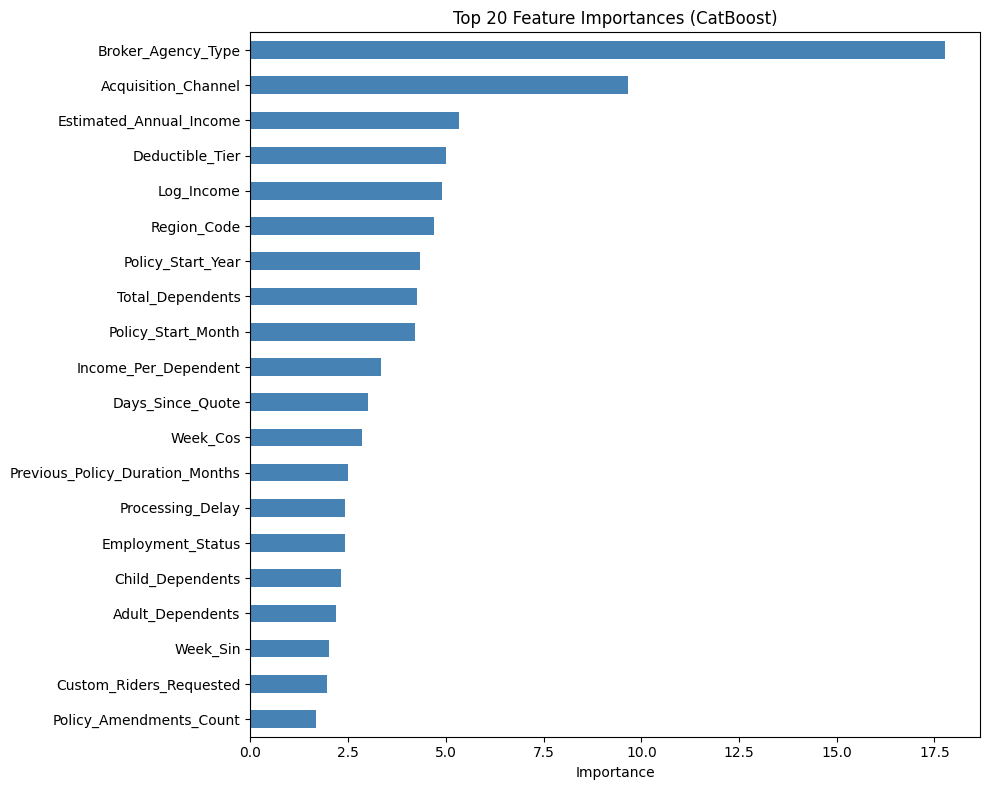

Broker_Agency_Type         17.775775
Acquisition_Channel         9.670993
Estimated_Annual_Income     5.330218
Deductible_Tier             5.008053
Log_Income                  4.907503
Region_Code                 4.705160
Policy_Start_Year           4.335232
Total_Dependents            4.253713
Policy_Start_Month          4.198724
Income_Per_Dependent        3.328266


In [9]:
fi = pd.Series(
    model.get_feature_importance(),
    index=model.feature_names_
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(20)[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances (CatBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(fi.head(10).to_string())

## 2. SHAP — CatBoost Native (no shap library, no crash)

In [10]:
# CatBoost computes SHAP internally in C++ — no TreeExplainer, no memory spike
# Drop User_ID (not a feature — causes float conversion error)
X_for_shap = X_explain.drop(columns=['User_ID'], errors='ignore')

active_cat = [c for c in cat_features if c in X_for_shap.columns]
pool       = Pool(X_for_shap, cat_features=active_cat)

# Returns shape: (n_samples, n_classes, n_features + 1)
# Last value per class is the bias term — drop it
shap_raw = model.get_feature_importance(pool, type='ShapValues')
shap_3d  = shap_raw[:, :, :-1]   # (n_samples, n_classes, n_features)

feature_names = X_for_shap.columns.tolist()
n_classes     = shap_3d.shape[1]

print(f'✅ SHAP computed — {shap_3d.shape[0]} samples, {n_classes} classes, {shap_3d.shape[2]} features')

✅ SHAP computed — 50 samples, 10 classes, 45 features


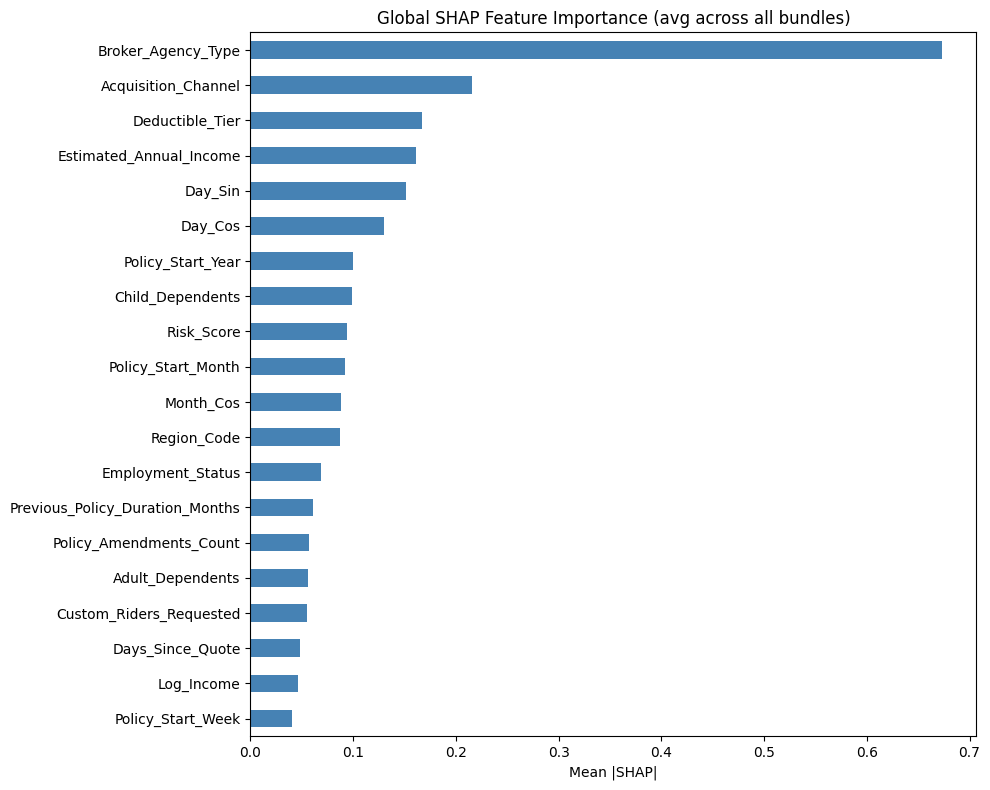

In [11]:
# Global importance — mean |SHAP| across all classes and samples
global_importance = np.abs(shap_3d).mean(axis=(0, 1))
fi_shap = pd.Series(global_importance, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi_shap.head(20)[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Global SHAP Feature Importance (avg across all bundles)')
plt.tight_layout()
plt.savefig('shap_global_bar.png', dpi=150)
plt.show()

## 3. SHAP — Per-Class Bar Charts (report-ready)

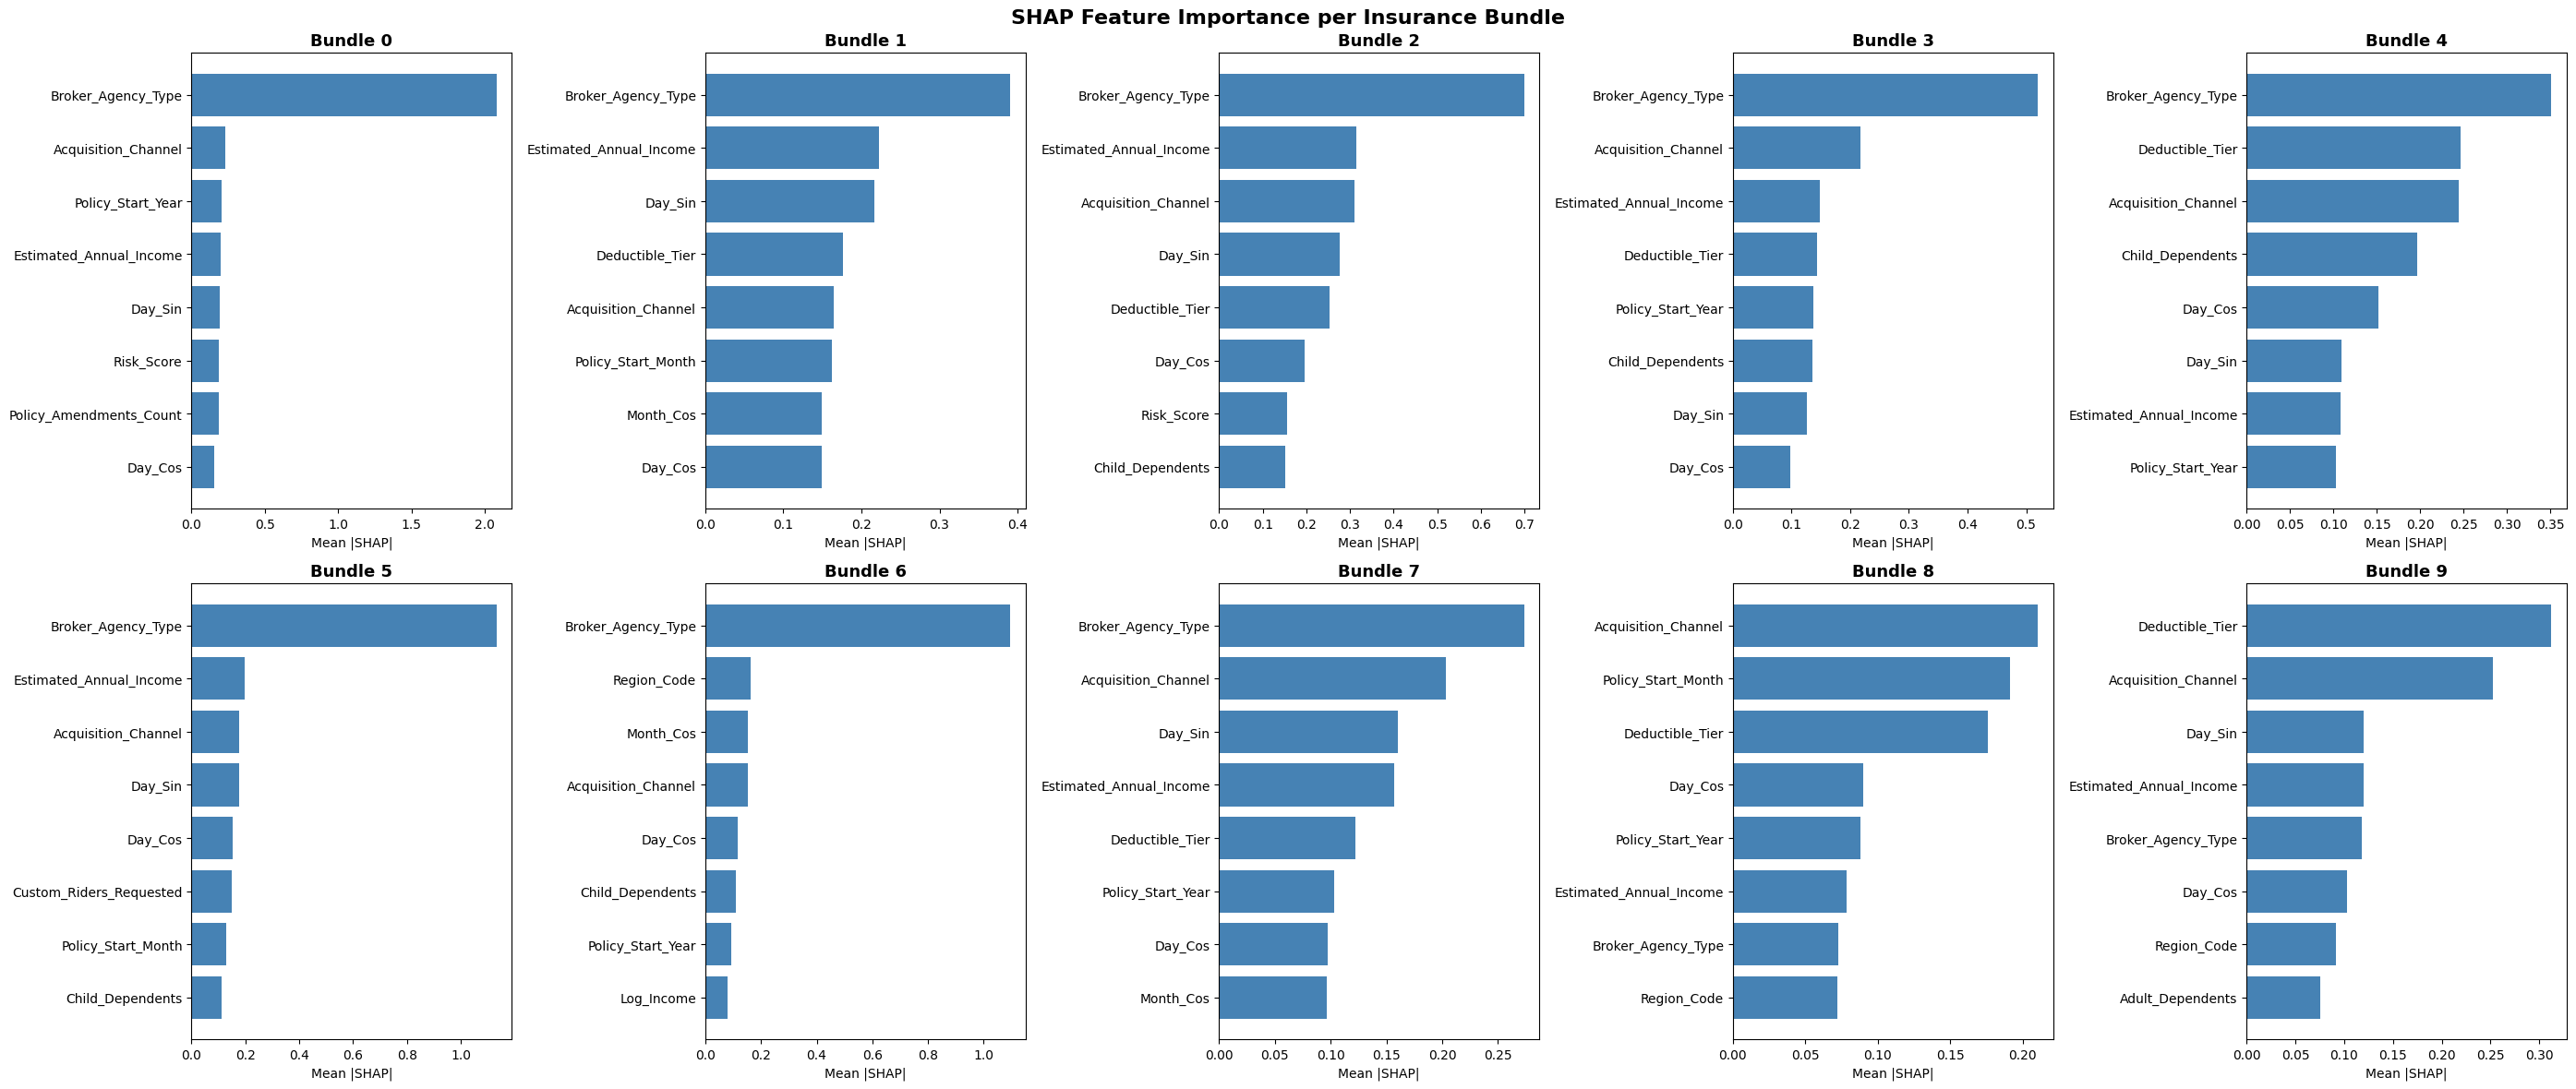

✅ Saved shap_per_class.png


In [12]:
fig, axes = plt.subplots(2, 5, figsize=(28, 12))

for i, ax in enumerate(axes.flat):
    if i >= n_classes:
        ax.axis('off')
        continue
    sv  = np.abs(shap_3d[:, i, :]).mean(axis=0)
    top = pd.Series(sv, index=feature_names).nlargest(8).sort_values()
    ax.barh(top.index, top.values, color='steelblue')
    ax.set_title(f'Bundle {i}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')

fig.suptitle('SHAP Feature Importance per Insurance Bundle', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved shap_per_class.png')

## 4. Waterfall — Single Prediction Explanation (for demo/UI)

C:\Users\MSI\AppData\Local\Temp\ipykernel_28784\2834344128.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_class = int(model.predict(sample)[0])


Predicted bundle: 2


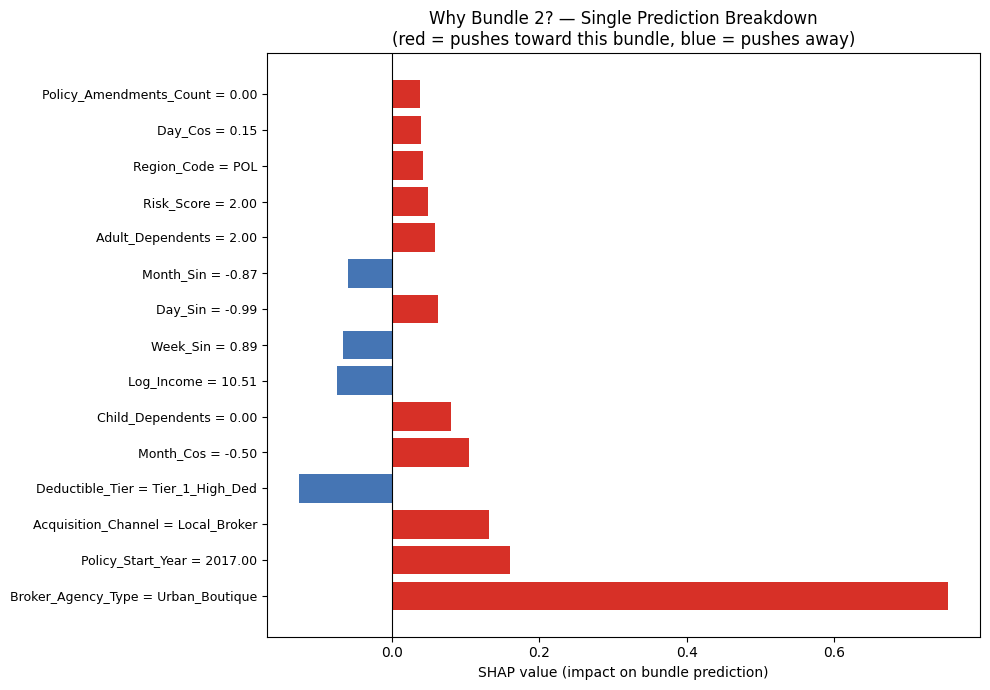

In [15]:
sample_idx = 0
sample     = X_explain.iloc[[sample_idx]].drop(columns=['User_ID'], errors='ignore')
pred_class = int(model.predict(sample)[0])
print(f'Predicted bundle: {pred_class}')

sv_sample = shap_3d[sample_idx, pred_class, :]

# Sort by absolute value, show top 15
top_n     = 15
order     = np.argsort(np.abs(sv_sample))[::-1][:top_n]
top_vals  = sv_sample[order]
top_names = [feature_names[j] for j in order]
top_data  = sample.iloc[0].values[order]
colors    = ['#d73027' if v > 0 else '#4575b4' for v in top_vals]

# Format labels — handle both numeric and categorical
labels = []
for n, v in zip(top_names, top_data):
    try:
        labels.append(f'{n} = {float(v):.2f}')
    except (ValueError, TypeError):
        labels.append(f'{n} = {str(v)[:20]}')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(top_n), top_vals, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on bundle prediction)')
ax.set_title(f'Why Bundle {pred_class}? — Single Prediction Breakdown\n(red = pushes toward this bundle, blue = pushes away)')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary Table for Technical Report

In [16]:
rows = []
for i in range(n_classes):
    sv   = np.abs(shap_3d[:, i, :]).mean(axis=0)
    top5 = pd.Series(sv, index=feature_names).nlargest(5)
    rows.append({'Bundle': i, 'Top Features': ', '.join(top5.index.tolist())})

report_table = pd.DataFrame(rows)
print(report_table.to_string(index=False))
report_table.to_csv('shap_top_features_per_bundle.csv', index=False)
print('\n✅ Saved shap_top_features_per_bundle.csv')

 Bundle                                                                                         Top Features
      0         Broker_Agency_Type, Acquisition_Channel, Policy_Start_Year, Estimated_Annual_Income, Day_Sin
      1           Broker_Agency_Type, Estimated_Annual_Income, Day_Sin, Deductible_Tier, Acquisition_Channel
      2           Broker_Agency_Type, Estimated_Annual_Income, Acquisition_Channel, Day_Sin, Deductible_Tier
      3 Broker_Agency_Type, Acquisition_Channel, Estimated_Annual_Income, Deductible_Tier, Policy_Start_Year
      4                  Broker_Agency_Type, Deductible_Tier, Acquisition_Channel, Child_Dependents, Day_Cos
      5                   Broker_Agency_Type, Estimated_Annual_Income, Acquisition_Channel, Day_Sin, Day_Cos
      6                             Broker_Agency_Type, Region_Code, Month_Cos, Acquisition_Channel, Day_Cos
      7           Broker_Agency_Type, Acquisition_Channel, Day_Sin, Estimated_Annual_Income, Deductible_Tier
      8            